# Chapter 2: Data Hygiene & Overfitting Prevention

> *"When a measure becomes a target, it ceases to be a good measure."* — **Goodhart's Law**

When automated prompt optimizers (or human engineers) iteratively hill-climb on a fixed benchmark without a strict **Holdout Gate**, mutations quickly transition from **genuine reasoning improvements** to **reward hacking** (e.g., overfitting to specific task phrasing, memorizing edge-case regexes, or biasing toward tool schemas over-represented in the training split).

---

## 1. Mathematical & Experimental Formulation

Let a benchmark $\mathcal{D}$ of $N=200$ tasks be partitioned into an **Optimization Set** $\mathcal{D}_{\text{opt}}$ ($60\%, n=120$) and an **Unseen Holdout Set** $\mathcal{D}_{\text{hold}}$ ($40\%, n=80$) via **joint stratification** over Difficulty Tier $D \in \{\text{Easy}, \text{Medium}, \text{Hard}\}$ and Capability Tag $C \in \{\text{tool\_selection}, \text{context\_retrieval}, \text{code\_execution}\}$:
$$\mathbb{P}(D = d, C = c \mid \mathcal{D}_{\text{opt}}) = \mathbb{P}(D = d, C = c \mid \mathcal{D}_{\text{hold}}) = \mathbb{P}(D = d, C = c \mid \mathcal{D})$$

At each prompt mutation step $t \in \{1, \dots, 30\}$, the candidate prompt $\pi_t$ produces:
$$\hat{R}_{\text{opt}}(\pi_t) = \mu(\pi_t) + \epsilon_{\text{quirk}}(\pi_t), \qquad \hat{R}_{\text{hold}}(\pi_t) = \mu(\pi_t) - \delta_{\text{brittle}}(\pi_t)$$
where $\epsilon_{\text{quirk}}(\pi_t) > 0$ is spurious overfitting to $\mathcal{D}_{\text{opt}}$ quirks and $\delta_{\text{brittle}}(\pi_t) > 0$ is the generalization penalty on unseen tasks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from agent_stats.ch02_hygiene_overfitting import (
    HoldoutGate,
    generate_synthetic_benchmark,
    run_prompt_hill_climbing_simulation,
    stratified_benchmark_split,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

df_bench = generate_synthetic_benchmark(num_tasks=200, random_state=42)
opt_df, holdout_df = stratified_benchmark_split(df_bench, holdout_fraction=0.40, random_state=42)
print(f"Total Tasks: {len(df_bench)} | Optimization Set (60%): {len(opt_df)} | Holdout Set (40%): {len(holdout_df)}")

Total Tasks: 200 | Optimization Set (60%): 120 | Holdout Set (40%): 80


## 2. Verifying Joint Stratification Across Difficulty & Capability

In [2]:
comparison = pd.DataFrame({
    "Opt Set Share (%)": (opt_df["stratum"].value_counts(normalize=True) * 100).round(1),
    "Holdout Set Share (%)": (holdout_df["stratum"].value_counts(normalize=True) * 100).round(1),
    "Opt Count": opt_df["stratum"].value_counts(),
    "Holdout Count": holdout_df["stratum"].value_counts(),
}).sort_index()
comparison

,Opt Set Share (%),Holdout Set Share (%),Opt Count,Holdout Count
stratum,,,,
Easy__code_execution,11.7,12.5,14,10
Easy__context_retrieval,14.2,13.8,17,11
Easy__tool_selection,14.2,13.8,17,11
Hard__code_execution,8.3,7.5,10,6
Hard__context_retrieval,8.3,7.5,10,6
Hard__tool_selection,9.2,8.8,11,7
Medium__code_execution,10.8,11.2,13,9
Medium__context_retrieval,11.7,12.5,14,10
Medium__tool_selection,11.7,12.5,14,10


## 3. Automated Prompt Hill-Climbing Loop & `HoldoutGate`

We now simulate 30 sequential prompt mutations comparing:
1. **Ungated Hill-Climbing**: Accepts any prompt mutation that improves the Optimization Set score ($\ge +0.4\%$), blind to holdout degradation.
2. **Holdout-Gated Hill-Climbing (`HoldoutGate`)**: Evaluates candidate mutations on the unseen Holdout Set and automatically rejects overfit / reward-hacking mutations.

In [3]:
history_df, gate = run_prompt_hill_climbing_simulation(opt_df, holdout_df, num_steps=30, random_state=42)

# Identify the divergence point where Ungated Opt - Ungated Holdout exceeds 5 percentage points
gen_gap = history_df["ungated_opt_pass_rate"] - history_df["ungated_holdout_pass_rate"]
divergence_step = int(history_df.loc[gen_gap > 0.05, "step"].iloc[0])

print(f"Overfitting Divergence Point detected at Step {divergence_step}!")
print(f"Final Ungated Optimization Pass Rate : {history_df['ungated_opt_pass_rate'].iloc[-1]:.1%}")
print(f"Final Ungated Holdout Pass Rate      : {history_df['ungated_holdout_pass_rate'].iloc[-1]:.1%} (Overfit Collapse!)")
print(f"Final Holdout-Gated Holdout Pass Rate: {history_df['gated_holdout_pass_rate'].iloc[-1]:.1%} (Protected Generalization!)")

history_df[["step", "mutation_type", "ungated_opt_pass_rate", "ungated_holdout_pass_rate", "gated_holdout_pass_rate", "gated_accepted", "gate_reason"]].tail(12)

Overfitting Divergence Point detected at Step 4!
Final Ungated Optimization Pass Rate : 98.0%
Final Ungated Holdout Pass Rate      : 47.8% (Overfit Collapse!)
Final Holdout-Gated Holdout Pass Rate: 69.8% (Protected Generalization!)


,step,mutation_type,ungated_opt_pass_rate,ungated_holdout_pass_rate,gated_holdout_pass_rate,gated_accepted,gate_reason
19,19,neutral_noise,0.900810,0.484425,0.646269,False,Rejected (Opt delta -1.00% < +0.40%)
20,20,reward_hacking,0.922356,0.476465,0.646269,False,Rejected by Holdout Gate (Holdout regressed -0...
21,21,reward_hacking,0.946225,0.459313,0.646269,False,Rejected by Holdout Gate (Holdout regressed -1...
22,22,genuine_capability,0.959820,0.470884,0.657839,True,"Accepted (Opt +1.36%, Holdout +1.16%)"
23,23,genuine_capability,0.975748,0.489380,0.676335,True,"Accepted (Opt +1.59%, Holdout +1.85%)"
24,24,reward_hacking,0.980000,0.477610,0.676335,False,Rejected by Holdout Gate (Holdout regressed -1...
25,25,reward_hacking,0.980000,0.477610,0.676335,False,Rejected by Holdout Gate (Holdout regressed -0...
26,26,neutral_noise,0.980000,0.477610,0.676335,False,Rejected (Opt delta -0.32% < +0.40%)
27,27,reward_hacking,0.980000,0.477610,0.676335,False,Rejected by Holdout Gate (Holdout regressed -1...
28,28,genuine_capability,0.980000,0.477610,0.697983,True,"Accepted (Opt +2.34%, Holdout +2.16%)"


## 4. Visualization: Goodhart's Law Divergence vs. Holdout Gate Protection

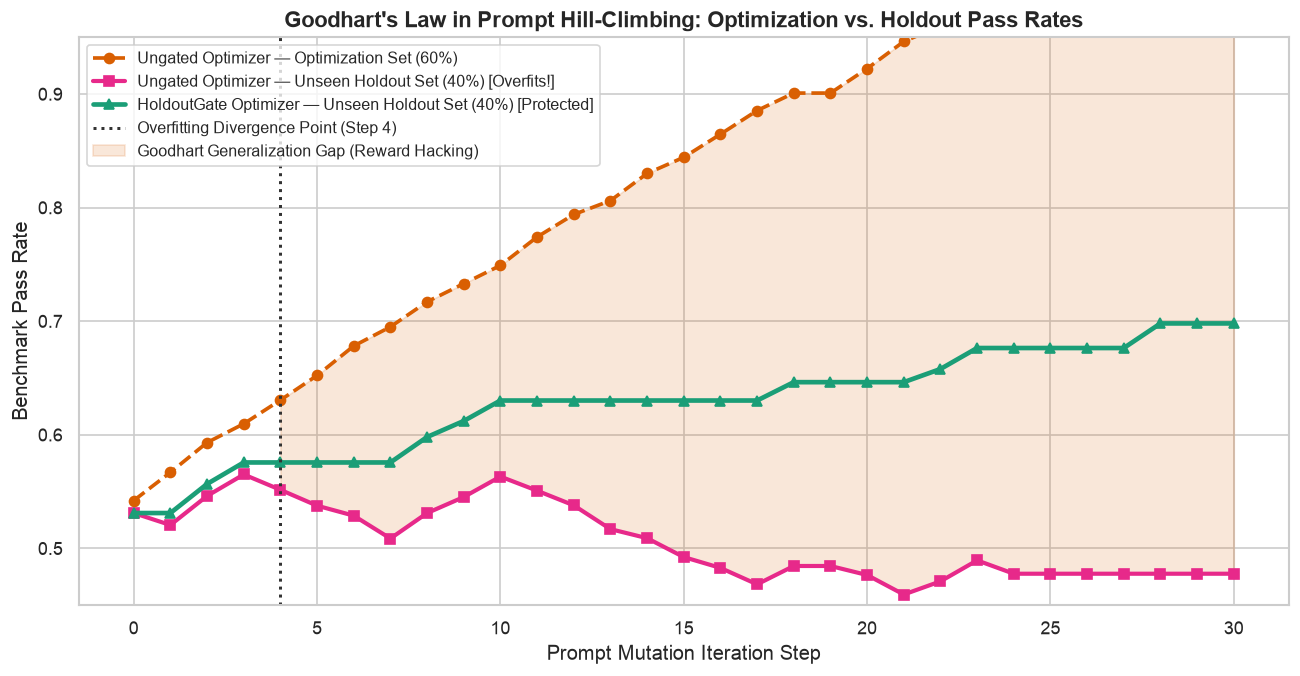

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.8))

steps = history_df["step"]
ax.plot(steps, history_df["ungated_opt_pass_rate"], "o--", color="#d95f02", linewidth=2.2, label="Ungated Optimizer — Optimization Set (60%)")
ax.plot(steps, history_df["ungated_holdout_pass_rate"], "s-", color="#e7298a", linewidth=2.5, label="Ungated Optimizer — Unseen Holdout Set (40%) [Overfits!]")
ax.plot(steps, history_df["gated_holdout_pass_rate"], "^-", color="#1b9e77", linewidth=2.8, label="HoldoutGate Optimizer — Unseen Holdout Set (40%) [Protected]")

ax.axvline(divergence_step, color="#333333", linestyle=":", linewidth=1.8, label=f"Overfitting Divergence Point (Step {divergence_step})")
ax.fill_between(
    steps,
    history_df["ungated_holdout_pass_rate"],
    history_df["ungated_opt_pass_rate"],
    where=(steps >= divergence_step),
    color="#d95f02",
    alpha=0.15,
    label="Goodhart Generalization Gap (Reward Hacking)",
)

ax.set_title("Goodhart's Law in Prompt Hill-Climbing: Optimization vs. Holdout Pass Rates", fontsize=13, fontweight="bold")
ax.set_xlabel("Prompt Mutation Iteration Step")
ax.set_ylabel("Benchmark Pass Rate")
ax.set_ylim(0.45, 0.95)
ax.legend(loc="upper left", fontsize=9.5)

plt.tight_layout()
plt.savefig("figures/ch02_goodharts_law_holdout_gate.png", dpi=150, bbox_inches="tight")
plt.show()